In [23]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import ast

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#convert skill list column into a list
def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)  
    return skill_list  # Return the original NaN value

df['job_skills'] = df['job_skills'].apply(clean_list)

Text(0, 0.5, '')

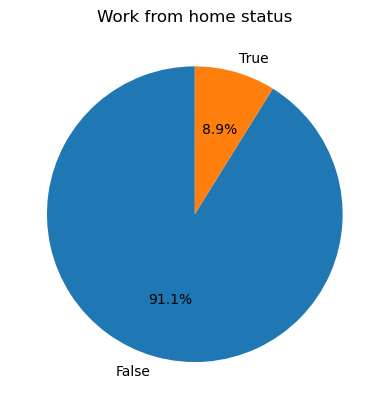

In [24]:
df['job_work_from_home'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%')
plt.title('Work from home status')
plt.ylabel("")

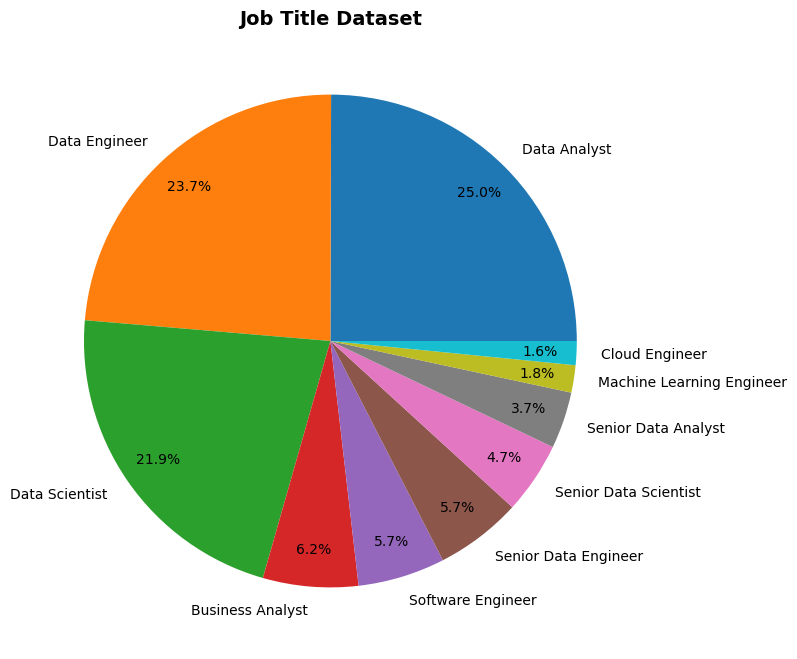

In [25]:
df['job_title_short'].value_counts().plot(
    kind='pie', 
    startangle=0, 
    autopct='%1.1f%%',
    pctdistance=0.85,  # Moves percentage labels closer to center
    labeldistance=1.1,  # Moves category labels further from center
    figsize=(10, 8)
)
plt.title('Job Title Dataset', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


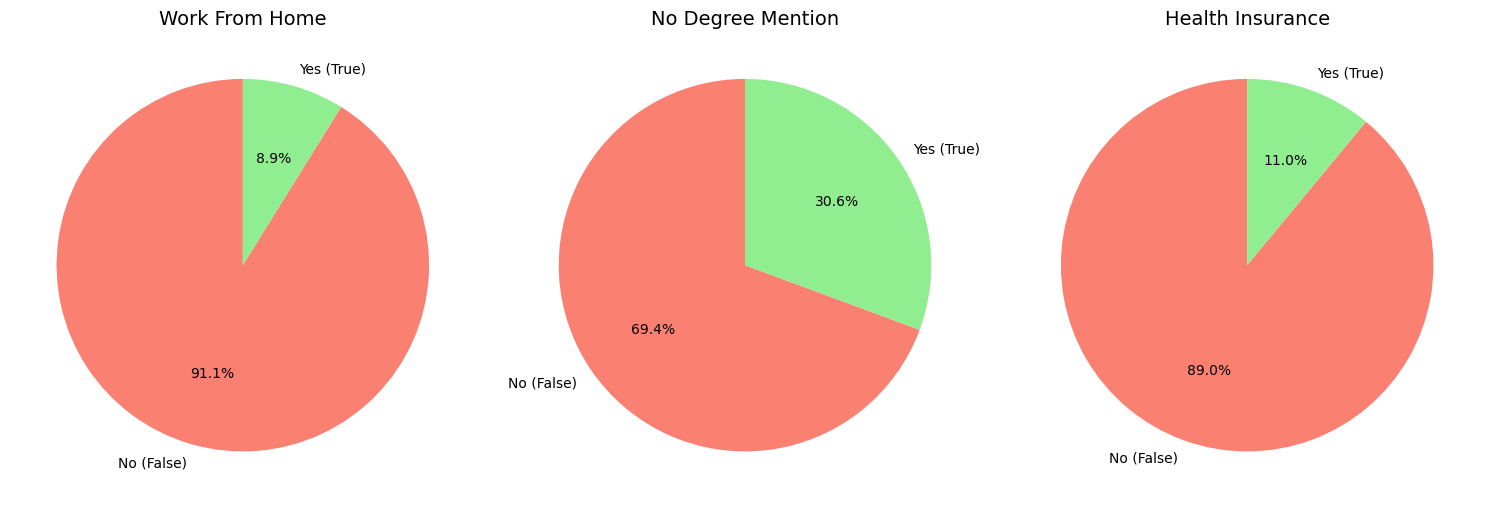

In [44]:
# Considering the columns that provide boolean values
# Plot different subplots as pie charts

# Create list of columns to analyze
columns = ['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance']

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(columns):
    # Get value counts (True and False)
    counts = df[col].value_counts()
    
    # Create pie chart with True as green, False as salmon/red
    axes[i].pie(counts, labels=['No (False)', 'Yes (True)'], autopct='%1.1f%%', 
                colors=['salmon', 'lightgreen'], startangle=90)
    axes[i].set_title(col.replace('job_', '').replace('_', ' ').title(), fontsize=14)

plt.tight_layout()
plt.show()